# Airline-Bookings — a quantitative teardown 🔬
### predictive vs contemporaneous HAC-*t* · block-shuffle placebo · timing rule net of costs & borrow · six-window sweep · seed-robust synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Already_in_the_price%3F: Confirmed](https://img.shields.io/badge/Already_in_the_price%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test whether a flight-booking momentum signal **leads** airline-basket returns (a tradable forward edge) or merely **co-moves** with them (already-priced).

> ⚠️ **Synthetic-only.** No free, point-in-time flight-bookings index is retail-reachable (the real card-panel / GDS feeds are paywalled), so a `REAL` stamp is impossible — the ceiling is `WEAK`. The headline world is the efficient-market case (`lead_beta=0`, `contemp_beta=0.9`, seed 554, 180 months, frame fp `fb00515e49fb`, as-of 2026-06-30). Numbers mirror [`docs/results.md`](../docs/results.md); methods in [`docs/references.md`](../docs/references.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from airline_bookings import data, strategy as st

# Synthetic-only: no free flight-bookings index exists. The headline world is the realistic
# efficient-market case -- bookings co-move with the sector (contemp_beta=0.9) but carry NO
# forward information (lead_beta=0). Everything below recomputes from this deterministic frame.
FRAME, TRUTH = data.synthetic_series(lead_beta=0.0, contemp_beta=0.9, seed=554)
HAVE_REAL = not data.fetch_series(fetch=False).empty     # False by design (no real tape)
print("synthetic frame:", len(FRAME), "months", FRAME.index[0].date(), "->", FRAME.index[-1].date(),
      "| fp", data.fingerprint(FRAME), "| real tape present:", HAVE_REAL)


synthetic frame: 180 months 2011-01-31 -> 2025-12-31 | fp fb00515e49fb | real tape present: False


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Predictive slope HAC *t* **-0.07** (corr **-0.005**, placebo *p* **0.943**); sign wanders across sub-samples. Synthetic-only ⇒ capped at `WEAK` regardless. |
| **Tradability** | `MIRAGE` | Long/flat nets **-0.5%/yr** vs buy-and-hold **+3.3%/yr** (-3.8 pp); long/short nets **-5.6%/yr** after 300 bps borrow. |
| **Already in the price?** | `CONFIRMED` | *Contemporaneous* slope HAC *t* **+12.61** (corr **+0.66**) vs a dead *forward* slope. |

> 💡 In plain words: the engine works (the synthetic control proves it), but the forward signal is noise while the same-month co-move is enormous — the classic already-priced alt-data trap.

## 1 · The claim, steelmanned

Let $b_t$ be booking momentum at month $t$ and $r_t$ the airline basket's return in month $t$.

- **H₁ (the lead / tradable).** In $r_{t+1} = \alpha + \beta\, b_t + \varepsilon$, $\beta > 0$ at HAC *t* ≥ 2 (this month's bookings forecast next month's return).
- **H₂ (contemporaneous).** In $r_t = a + c\, b_t + u$, $c > 0$ (they co-move). This is the *vendor's* chart — and it can be true while H₁ is false.
- **H₃ (tradable net).** A sign-of-momentum timing rule beats buy-and-hold after costs and short borrow.
- **H₄ (robustness).** The sign of H₁ is stable across sub-samples.

We find **H₂ overwhelmingly true**, **H₁ rejected** (forward $\beta$ is noise), **H₃ rejected** (timing loses to holding), and **H₄ rejected** (the forward *t* flips sign across windows). H₂-true / H₁-false *is* the already-priced signature.

## 2 · So what? — what rides on each answer

The content is the **why an alt-data lead decays**. Even a signal that genuinely leads *fundamentals* need not lead *returns*: a forward-looking market (Fama 1970) prices the demand as soon as it is discernible, so a *public* booking print forecasts the earnings but not the price move. Grossman-Stiglitz (1980) sharpens it — a widely-sold feed erodes its own forward edge as it is priced in. This study is the clean instance: a booking signal with a huge contemporaneous loading and a zero forward one.

## 3 · How we'd know — the protocol

- **Signal.** Monthly booking momentum $b_t$ (a noisy read of a persistent latent travel-demand shock).
- **Predictive regression (H₁).** OLS of $r_{t+1}$ on $b_t$, reporting a **Newey-West** HAC *t* (lag 3) alongside the OLS *t* — the desk's autocorrelation-robust bar.
- **Contemporaneous regression (H₂).** OLS of $r_t$ on $b_t$.
- **Placebo.** Circular block-shuffle (block 6) of $b$ against forward returns, 2000 perms; the fraction with |HAC *t*| ≥ observed.
- **Trading rule (H₃).** Long/flat and long/short on $\text{sign}(b_t)$, held one month, one-way 10 bps per rebalance, short leg pays 300 bps/yr borrow; vs buy-and-hold.
- **Robustness (H₄).** Predictive HAC *t* over full / halves / thirds.
- **Positive control.** A deterministic world with a planted lead (`lead_beta > 0`) and a null — averaged over 25 seeds (house rule).

Timing: $b_t$ uses only data through month $t$'s close; the traded return is $r_{t+1}$. That one-month lag is the single documented execution convention (no look-ahead).

## 4 · The teardown

### 4a · Predictive vs contemporaneous — H₁ vs H₂

The same signal, regressed on *this*-month and *next*-month returns.

                      slope   OLS t   HAC t   corr
contemporaneous (H2)  0.055  11.657  12.606  0.658
predictive (H1)      -0.000  -0.068  -0.073 -0.005


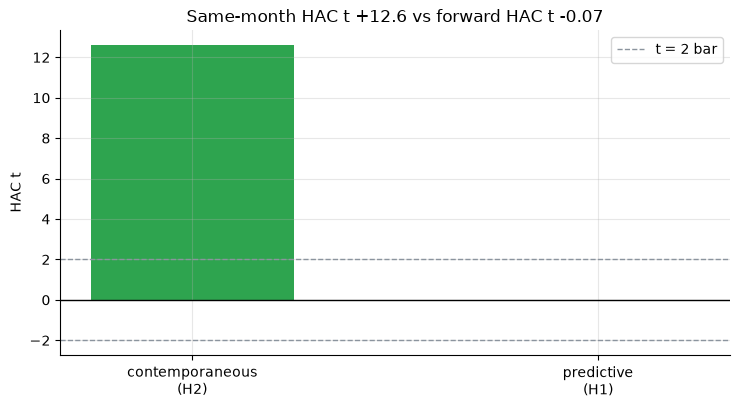

In [2]:
c = st.contemporaneous_regression(FRAME)
p = st.predictive_regression(FRAME)
tab = pd.DataFrame({
  'slope': [c['slope'], p['slope']],
  'OLS t': [c['t_ols'], p['t_ols']],
  'HAC t': [c['t_hac'], p['t_hac']],
  'corr':  [c['corr'], p['corr']],
}, index=['contemporaneous (H2)', 'predictive (H1)'])
print(tab.round(3).to_string())
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.bar(['contemporaneous\n(H2)', 'predictive\n(H1)'], [c['t_hac'], p['t_hac']],
       color=[GREEN, RED], width=.5)
ax.axhline(2, ls='--', c=GREY, lw=1, label='t = 2 bar'); ax.axhline(-2, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('HAC t')
ax.set_title(f"Same-month HAC t +{c['t_hac']:.1f} vs forward HAC t {p['t_hac']:+.2f}")
ax.legend(); plt.tight_layout(); plt.show()

> 💡 In plain words: **H₂ crushes it, H₁ is dead.** Same-month HAC *t* **+12.61** (corr **+0.66**) — bookings and the airline return are tightly linked *now*. Forward HAC *t* **-0.07** (corr **-0.005**) — the booking print says nothing about next month. That split is the already-priced signature.

### 4b · The placebo — is the forward *t* even distinguishable from noise?

Circular block-shuffle the signal against forward returns; where does the observed forward |HAC *t*| land?

In [3]:
pp = st.placebo_pvalue(FRAME, n_perm=2000, block=6)
print(f'predictive placebo p = {pp:.3f}  (fraction of shuffles with |HAC t| >= observed)')
# and show the test HAS teeth: plant a real lead, re-run the placebo
frame_pos, _ = data.synthetic_series(lead_beta=0.75, contemp_beta=0.9, seed=554)
pp_pos = st.placebo_pvalue(frame_pos, n_perm=2000, block=6)
t_pos = st.predictive_regression(frame_pos)['t_hac']
print(f'planted lead (0.75): forward HAC t {t_pos:+.2f}, placebo p {pp_pos:.4f}')

predictive placebo p = 0.943  (fraction of shuffles with |HAC t| >= observed)


planted lead (0.75): forward HAC t +7.73, placebo p 0.0005


> 💡 In plain words: the headline forward |*t*| sits at the **94th** percentile of shuffled noise (*p* = **0.943**) — squarely in the bulk. The test is not blind: plant a real lead and it fires (*t* +7.73, placebo *p* **0.0005**). The headline world simply has no forward signal.

### 4c · The trading rule — H₃, gross and net

Sign-of-momentum timing vs buy-and-hold, after costs and (for the short) borrow.

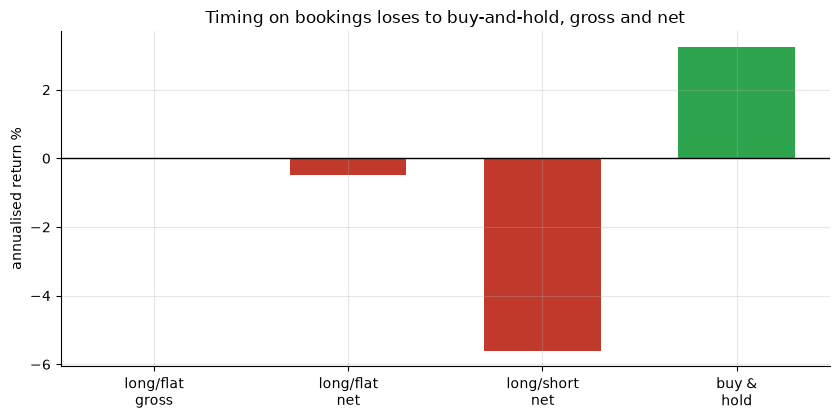

long/flat  gross -0.0%  net -0.5%  (71 trades)
long/short net -5.6%  (143 trades, 300 bps borrow)
buy-and-hold   +3.3%/yr


In [4]:
lf = st.timing_rule(FRAME, mode='long_flat', cost_bps=10.0)
ls = st.timing_rule(FRAME, mode='long_short', cost_bps=10.0, borrow_ann_bps=300.0)
labels = ['long/flat\ngross','long/flat\nnet','long/short\nnet','buy &\nhold']
vals = [lf['gross_ann']*100, lf['net_ann']*100, ls['net_ann']*100, lf['bh_ann']*100]
cols = [AMBER, RED, RED, GREEN]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.bar(labels, vals, color=cols, width=.6); ax.axhline(0, c='k', lw=1)
ax.set_ylabel('annualised return %')
ax.set_title('Timing on bookings loses to buy-and-hold, gross and net')
plt.tight_layout(); plt.show()
print(f"long/flat  gross {lf['gross_ann']*100:+.1f}%  net {lf['net_ann']*100:+.1f}%  ({lf['n_trades']} trades)")
print(f"long/short net {ls['net_ann']*100:+.1f}%  ({ls['n_trades']} trades, {300} bps borrow)")
print(f"buy-and-hold   {lf['bh_ann']*100:+.1f}%/yr")

> 💡 In plain words: **H₃ rejected.** Long/flat nets **-0.5%/yr** vs buy-and-hold **+3.3%/yr** (-3.8 pp); long/short bleeds **-5.6%/yr** after borrow. Timing on a noise signal just pays costs.

### 4d · Robustness — H₄ (does the forward sign hold?)

Predictive HAC *t* over the full sample, halves and thirds.

             slope  t_hac    n
window                        
full        -0.000 -0.073  180
first half   0.004  0.696   90
second half -0.006 -0.926   90
third 1     -0.002 -0.266   60
third 2      0.000  0.050   60
third 3     -0.004 -0.510   60


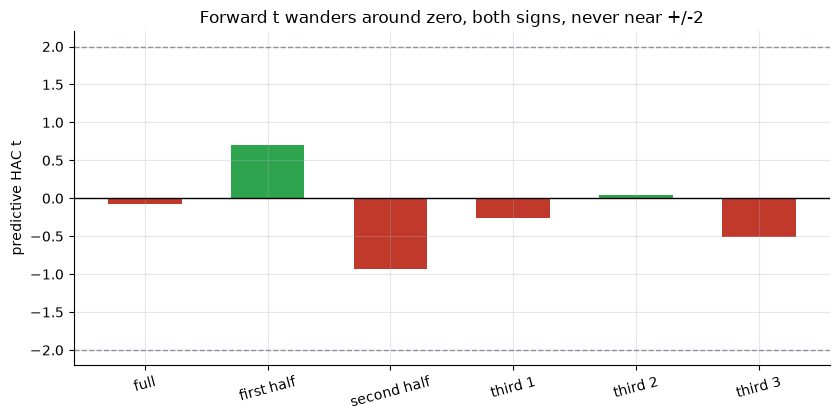

In [5]:
rob = st.robustness_windows(FRAME)
print(rob.round(3).to_string())
fig, ax = plt.subplots(figsize=(8.5, 4.3))
cols = [GREEN if t>0 else RED for t in rob['t_hac']]
ax.bar(range(len(rob)), rob['t_hac'], color=cols, width=.6)
ax.set_xticks(range(len(rob))); ax.set_xticklabels(rob.index, rotation=15)
ax.axhline(2, ls='--', c=GREY, lw=1); ax.axhline(-2, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('predictive HAC t')
ax.set_title('Forward t wanders around zero, both signs, never near +/-2')
plt.tight_layout(); plt.show()

> 💡 In plain words: **H₄ rejected.** No sub-sample clears |*t*| = 2 and the sign flips between halves and thirds — a forward lead that is not present in any window.

## 5 · The verdict

- **Signal `NONE`** — H₁ rejected (forward HAC *t* -0.07, placebo *p* 0.943); H₄ rejected (sign flips). Synthetic-only ⇒ `WEAK` ceiling anyway.
- **Tradability `MIRAGE`** — H₃ rejected; long/flat -0.5%/yr vs buy-and-hold +3.3%/yr.
- **Already in the price? `CONFIRMED`** — H₂ overwhelming (contemporaneous HAC *t* +12.61) with a dead forward slope.

## 6 · Could you trade it? — the costs are almost a footnote

There is no forward edge to charge costs against; the rule is a coin flip that then pays 10 bps a rebalance and, short, 300 bps/yr borrow. The `MIRAGE` is decided *before* frictions — the frictions just deepen it (see 4c).

## 7 · Going further — the synthetic positive control

Is the engine a faithful detector, or would it print ~0 no matter what? Plant a genuine forward lead (`lead_beta > 0`) of increasing strength and watch the predictive HAC *t* climb — averaged over 25 seeds so no single lucky seed can fake it.

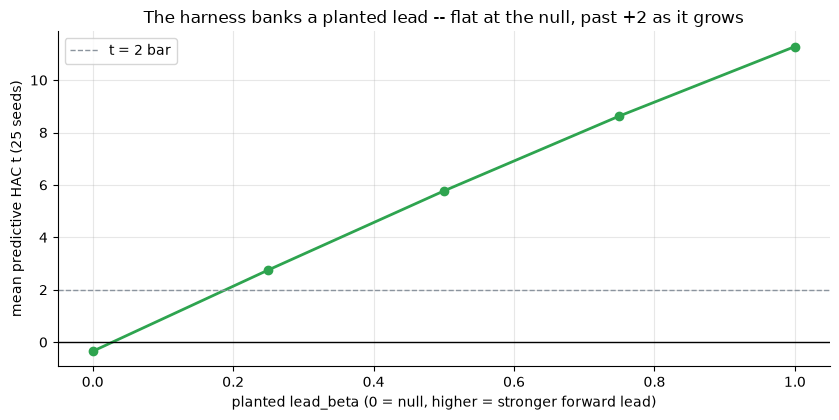

lead_beta +0.00 -> mean HAC t -0.35
lead_beta +0.25 -> mean HAC t +2.75
lead_beta +0.50 -> mean HAC t +5.77
lead_beta +0.75 -> mean HAC t +8.63
lead_beta +1.00 -> mean HAC t +11.28


In [6]:
leads = [0.0, 0.25, 0.5, 0.75, 1.0]
ts = [st.synthetic_mean_t(data, lead_beta=b, contemp_beta=0.9, n_seeds=25) for b in leads]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(leads, ts, 'o-', c=GREEN, lw=2)
ax.axhline(2, ls='--', c=GREY, lw=1, label='t = 2 bar')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted lead_beta (0 = null, higher = stronger forward lead)')
ax.set_ylabel('mean predictive HAC t (25 seeds)')
ax.set_title('The harness banks a planted lead -- flat at the null, past +2 as it grows')
ax.legend(); plt.tight_layout(); plt.show()
for b, t in zip(leads, ts): print(f'lead_beta {b:+.2f} -> mean HAC t {t:+.2f}')

The predictive HAC *t* is ≈ 0 at the null and climbs cleanly past +2 as the planted lead grows — so the engine is a faithful detector. The headline 'no forward edge' is therefore a statement about the **efficient-market world** (the realistic one), not a broken engine. For sibling alt-data leads see [257 AAII](../../257-aaii-sentiment/), [335 Buzz-ETF](../../335-buzz-sentiment-etf/) and [392 Glassdoor](../../392-glassdoor-sentiment/).